In [1]:
import os
import torch
from deeplsd.models.deeplsd_inference import DeepLSD
from line_understanding.pipeline import process_image_pipeline, plot_pipeline_results
from line_understanding.json_saver import save_lines_to_json 
import os
import cv2
import numpy as np
import torch
from numpy import linalg as LA
import matplotlib.pyplot as plt
from line_understanding.utility_methods import (
    raydepth2depth, load_color_image, load_depth_map,
    load_normal_map, load_world_coordinates, compute_variation, sobel_line, sigmoid
)
from line_understanding.image_processing import create_optimal_offset_lines, compute_shifted_line
from deeplsd.geometry.viz_2d import plot_images

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conf = {'detect_lines': True, 'line_detection_params': {'merge': False, 'filtering': True, 'grad_thresh': 3}}
ckpt = torch.load('../weights/deeplsd_md.tar', map_location='cpu', weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net = net.to(device).eval()



In [3]:
def process_image(image_dir, image_id, frame_str, net, device,
            depth_thresh=0.05, normal_thresh=0.5, thickness=1, structural_thresh=0.6,
            method="neighborhood", depth_normal_func=np.max,
            depth_normal_func_str="Max", norm_agg_func=np.linalg.norm,
            struct_color=(0, 0, 255), text_color=(255, 0, 0)):

    # Load image data using helper functions.
    cam_view_color = "scene_cam_00_final_preview"
    cam_view_geom = "scene_cam_00_geometry_hdf5"
    color_img = load_color_image(image_dir, image_id, frame_str, cam_view_color)
    normal_map = load_normal_map(image_dir, image_id, frame_str, cam_view_geom)
    depth_map = load_depth_map(image_dir, image_id, frame_str, cam_view_geom)
    world_coordinates_map = load_world_coordinates(image_dir, image_id, frame_str, cam_view_geom)

    if color_img is None or depth_map is None or normal_map is None:
        print(f"Missing data in {image_dir}; skipping processing.")
        return None, None, None, None, None, None, None, None, None

    h, w = color_img.shape[:2]
    fov_x = np.pi / 3 
    f = w / (2 * np.tan(fov_x / 2))
    default_K = np.array([[f, 0, w / 2], [0, f, h / 2], [0, 0, 1]])

    print(depth_map)
    print( depth_map - raydepth2depth(depth_map, default_K))
    depth_map = raydepth2depth(depth_map, default_K)
    gray_img = cv2.cvtColor(color_img, cv2.COLOR_RGB2GRAY)

    # Detect lines with DeepLSD.
    input_tensor = torch.tensor(gray_img, dtype=torch.float32, device=device)[None, None] / 255.
    with torch.no_grad():
        out = net({'image': input_tensor})
        pred_lines = out['lines'][0]
        if isinstance(pred_lines, torch.Tensor):
            pred_lines = pred_lines.cpu().numpy()

    # Compute variation maps.
    sobel_depth_map = compute_variation(depth_map, 11, depth=True)
    sobel_normal_map = compute_variation(normal_map, 27)
    sobel_normal_map = norm_agg_func(sobel_normal_map, axis=2)
    
    plt.figure()
    plot_images([sobel_depth_map], ["Depth sobel"], cmaps='gray')
    plt.show()
        
    # Classify each predicted line.
    is_struct = []
    is_depth_seperated  = []
    scores = []
    for l in pred_lines:
        ld, ln = sobel_line(sobel_depth_map, sobel_normal_map, l)
        scores.append(max(sigmoid(depth_normal_func(ln), lam=25, tau=normal_thresh),
                          sigmoid(depth_normal_func(ld), lam=250, tau=depth_thresh)))
        is_depth_seperated.append(sigmoid(depth_normal_func(ld), lam=250, tau=depth_thresh) > 0.5)
    is_struct = [s > structural_thresh for s in scores]
    
    print(f"[{method.capitalize()} Method] {os.path.basename(image_dir)}: Detected {len(pred_lines)} lines; {sum(is_struct)} structural.")

    non_structural_color = text_color
    structural_color1 = (128, 0, 128)  # purple
    structural_color2 = (0, 165, 255)   # orange

    composite_after = color_img.copy()
    new_lines_list = []  # List of all drawn lines (offsets for structural, original for textural)
    line_info = []       # Metadata for each base line

    for i, l in enumerate(pred_lines):
        line = l.reshape(2, 2) if l.shape == (4,) else l

        # Case 1: Structural line in low depth variation => split
        if is_struct[i] and not is_depth_seperated[i]:
            offset_amount = 1.0
            line1, line2 = create_optimal_offset_lines(line, normal_map, offset_amount=offset_amount)
            idx1 = len(new_lines_list)
            new_lines_list.append(line1)
            idx2 = len(new_lines_list)
            new_lines_list.append(line2)
            line_info.append({
                "base_line": line.tolist(),
                "score": scores[i],
                "offset_lines": [line1.tolist(), line2.tolist()],
                "new_line_indices": [idx1, idx2]
            })
            new_thickness = thickness + 1
            cv2.line(composite_after,
                     (int(round(line1[0, 0])), int(round(line1[0, 1]))),
                     (int(round(line1[1, 0])), int(round(line1[1, 1]))),
                     structural_color1, new_thickness)
            cv2.line(composite_after,
                     (int(round(line2[0, 0])), int(round(line2[0, 1]))),
                     (int(round(line2[1, 0])), int(round(line2[1, 1]))),
                     structural_color2, new_thickness)

        # Case 2: Structural line in high depth variation => shift by 1 pixel
        elif is_struct[i] and is_depth_seperated[i]:
            shifted_line = compute_shifted_line(line, depth_map, w, h, offset=1.0, num_samples=100)
            idx = len(new_lines_list)
            new_lines_list.append(shifted_line)
            line_info.append({
                "base_line": line.tolist(),
                "score": scores[i],
                "new_line_indices": [idx],
                "shifted": True
            })
            cv2.line(composite_after,
                     (int(round(shifted_line[0, 0])), int(round(shifted_line[0, 1]))),
                     (int(round(shifted_line[1, 0])), int(round(shifted_line[1, 1]))),
                     struct_color, thickness)

        # Case 3: Textural lines => let as is
        else:
            idx = len(new_lines_list)
            new_lines_list.append(line)
            line_info.append({
                "base_line": line.tolist(),
                "score": scores[i],
                "new_line_indices": [idx]
            })
            cv2.line(composite_after,
                     (int(round(line[0, 0])), int(round(line[0, 1]))),
                     (int(round(line[1, 0])), int(round(line[1, 1]))),
                     non_structural_color, thickness)

    composite_after_rgb = cv2.cvtColor(composite_after, cv2.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(composite_after_rgb)
    plt.axis("off")
    plt.show()

    new_lines_array = np.array(new_lines_list)
    return composite_after, new_lines_array, color_img, normal_map, world_coordinates_map, line_info, scores, is_struct, pred_lines

In [4]:
def process(image_id, frame_str, net, device, 
                           base_data_dir="data", 
                           depth_thresh=0.05, 
                           normal_thresh=0.5, 
                           thickness=1, 
                           depth_normal_func=lambda x: x.max(), 
                           norm_agg_func=lambda x, axis: np.linalg.norm(x, axis=axis)):
    
    image_dir = os.path.join(base_data_dir, image_id)
    composite_after, pred_lines, img, normals, world_coordinates, line_info, scores, isstruct, original_lines = process_image(
        image_dir, image_id, frame_str, net, device,
        depth_thresh, normal_thresh, thickness,
        depth_normal_func=depth_normal_func,
        norm_agg_func=norm_agg_func
    )

data/ai_001_008/ai_001_008/images/scene_cam_00_final_preview/frame.0001.color.jpg
data/ai_001_008/ai_001_008/images/scene_cam_00_geometry_hdf5/frame.0001.normal_world.hdf5
data/ai_001_008/ai_001_008/images/scene_cam_00_geometry_hdf5/frame.0001.depth_meters.hdf5
data/ai_001_008/ai_001_008/images/scene_cam_00_geometry_hdf5/frame.0001.position.hdf5
[[3.8632812 3.8613281 3.859375  ... 4.0546875 4.0546875 4.0546875]
 [3.8808594 3.8789062 3.8769531 ... 4.0703125 4.0703125 4.0742188]
 [3.8984375 3.8964844 3.8945312 ... 4.0859375 4.0898438 4.0898438]
 ...
 [3.5625    3.5605469 3.5585938 ... 3.6386719 3.640625  3.6425781]
 [3.5566406 3.5546875 3.5546875 ... 3.6328125 3.6347656 3.6367188]
 [3.5507812 3.5507812 3.5488281 ... 3.6289062 3.6289062 3.6308594]]
[[0.730605   0.72889572 0.72718869 ... 0.76258463 0.76398974 0.76539581]
 [0.73291976 0.73120359 0.72948968 ... 0.76446041 0.76587229 0.76802149]
 [0.73522705 0.73350398 0.73178318 ... 0.76632978 0.76848243 0.76990342]
 ...
 [0.67094715 0.66934

<Figure size 640x480 with 0 Axes>

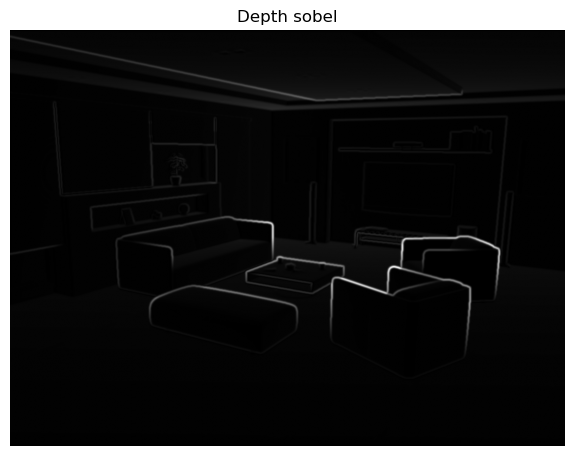

[Neighborhood Method] ai_001_008: Detected 441 lines; 441 structural.


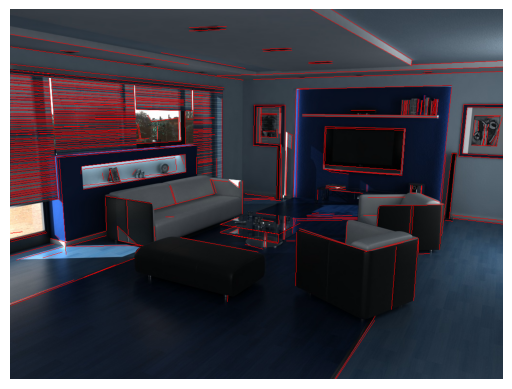

In [5]:

frame_str = "0001"
desired_images = [
    "ai_001_008",
]

# Process, plot, and save JSON data for each image.
for image_id in desired_images:
    processed_data = process(image_id, frame_str, net, device)


data/ai_001_008/ai_001_008/images/scene_cam_00_final_preview/frame.0001.color.jpg
data/ai_001_008/ai_001_008/images/scene_cam_00_geometry_hdf5/frame.0001.normal_world.hdf5
data/ai_001_008/ai_001_008/images/scene_cam_00_geometry_hdf5/frame.0001.depth_meters.hdf5
data/ai_001_008/ai_001_008/images/scene_cam_00_geometry_hdf5/frame.0001.position.hdf5
[[3.8632812 3.8613281 3.859375  ... 4.0546875 4.0546875 4.0546875]
 [3.8808594 3.8789062 3.8769531 ... 4.0703125 4.0703125 4.0742188]
 [3.8984375 3.8964844 3.8945312 ... 4.0859375 4.0898438 4.0898438]
 ...
 [3.5625    3.5605469 3.5585938 ... 3.6386719 3.640625  3.6425781]
 [3.5566406 3.5546875 3.5546875 ... 3.6328125 3.6347656 3.6367188]
 [3.5507812 3.5507812 3.5488281 ... 3.6289062 3.6289062 3.6308594]]
[[0.730605   0.72889572 0.72718869 ... 0.76258463 0.76398974 0.76539581]
 [0.73291976 0.73120359 0.72948968 ... 0.76446041 0.76587229 0.76802149]
 [0.73522705 0.73350398 0.73178318 ... 0.76632978 0.76848243 0.76990342]
 ...
 [0.67094715 0.66934

<Figure size 640x480 with 0 Axes>

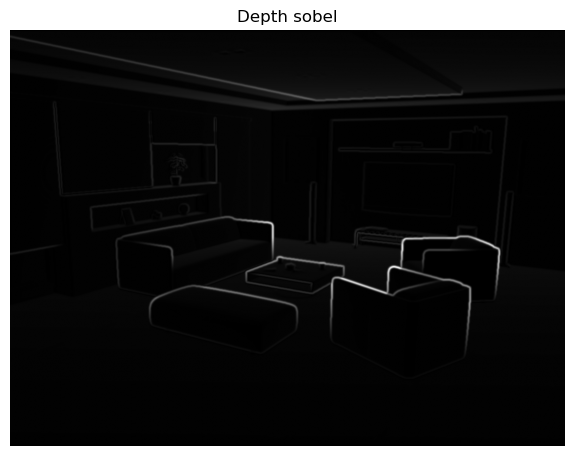

[Neighborhood Method] ai_001_008: Detected 441 lines; 118 structural.


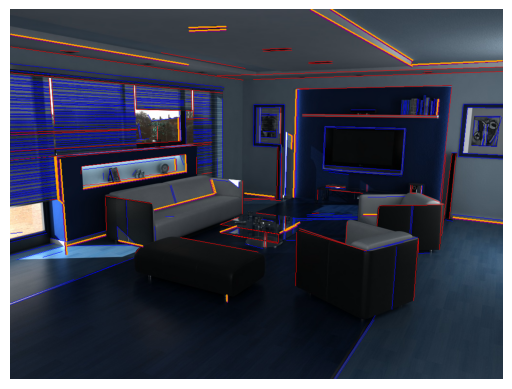

In [5]:

frame_str = "0001"
desired_images = [
    "ai_001_008",
]

# Process, plot, and save JSON data for each image.
for image_id in desired_images:
    processed_data = process(image_id, frame_str, net, device)

In [ ]:

frame_str = "0001"
desired_images = [
    "ai_001_008",
]

# Process, plot, and save JSON data for each image.
for image_id in desired_images:
    processed_data = process(image_id, frame_str, net, device)
